# Финальный экзамен (V1)

**Курс**: ML Spring 26  |  **Длительность**: 80 минут  |  **Итого**: 25 баллов

---

## Описание задачи

Вы работаете junior data scientist в телеком-компании. Команда готовит короткий аналитический отчет для data science lead: нужно пройти путь от первых проверок данных до финальной модели и показать, какие решения вы приняли.

В этом варианте цель проекта - предсказать срок жизни клиента в месяцах. Целевая переменная: `tenure` (сколько месяцев клиент остается с компанией).

Файл данных лежит рядом с ноутбуком: `telco_v1.csv`.


## Критерии оценивания

| # | Критерий | 0 баллов | 1 балл | 2 балла |
|---|----------|----------|--------|---------|
| **1.1** | `mae` | нет / не работает | - | формула верна, check пройден |
| **1.2** | `rmse` | нет / не работает | - | формула верна, check пройден |
| **2.1** | Загрузка | не загружен | shape + info + describe | - |
| **2.2** | Визуализация | 0-1 график | 2-3 графика | 4+ графика с подписями |
| **2.3** | Очистка данных | не сделана | customerID удален, пропуски проверены | - |
| **2.4** | Кодирование | не сделано | категориальные признаки закодированы | - |
| **2.5** | Целевая + X | не определены | y = tenure, X без target и customerID | - |
| **2.6** | Разбивка | нет или ошибки | train_test_split, random_state=42 | - |
| **3.1** | Baseline-модели | 0-1 модель | 2 модели обучены | 3+ модели обучены |
| **3.2** | Метрики | не посчитаны | MAE + RMSE + R2 для всех моделей | - |
| **3.3** | Визуализации | 0 графиков | 1 визуализация | bar chart метрик + predicted vs actual |
| **3.4** | Выбор лучшей | нет текста | обосновано с числами | - |
| **3.5** | Порог качества | не выведен / не достигнут | порог достигнут | - |
| **4.1** | Пайплайн | нет | Pipeline создан с 2 шагами | - |
| **4.2** | param_grid | нет | >=2 гиперпараметра | - |
| **4.3** | GridSearchCV | нет | fit + best_params_ | - |
| **4.4** | Финальная оценка | пороги не достигнуты | один порог достигнут | два порога достигнуты |
| **4.5** | Важность | нет | bar chart feature importances | - |
| **4.6** | Сравнение | нет | простой график best baseline vs tuned | - |
| | **Итого** | | | **25** |

Порог качества для этого варианта: R2 >= 0.40 / R2 >= 0.60.


---
## Импорты


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay,
)

np.random.seed(42)


---
## Задание 1 - Реализация функций на NumPy (4 балла)

Техническая разминка перед основной частью экзамена: реализуйте две базовые функции только через `numpy` и проверьте их через готовые `check_*()` ячейки.


### 1.1 - MAE (Mean Absolute Error) [2 балла]

**Описание задачи.** MAE показывает среднюю ошибку прогноза в исходных единицах задачи.

**Что сделать.** Реализуйте функцию `mae(y_true, y_pred)`.

**Ориентиры:**
- функция работает с обычными списками и NumPy-массивами
- результат соответствует средней абсолютной ошибке
- проверочная ячейка проходит без ошибок

**Документация:**
- <https://numpy.org/doc/stable/reference/generated/numpy.asarray.html>
- <https://numpy.org/doc/stable/reference/generated/numpy.absolute.html>
- <https://numpy.org/doc/stable/reference/generated/numpy.mean.html>


In [ ]:
def mae(y_true, y_pred):
    # y_true = ...
    # y_pred = ...
    pass


In [ ]:
def check_mae():
    assert abs(mae([1, 2, 3], [1, 2, 3])) < 1e-9, "Идеальный прогноз должен дать 0"
    assert abs(mae([0, 0], [3, 4]) - 3.5) < 1e-9
    assert abs(mae([10], [13]) - 3.0) < 1e-9
    assert abs(mae([0, 0, 0, 0], [0, 0, 0, 8]) - 2.0) < 1e-9
    print("1.1 mae: проверки пройдены")

check_mae()


### 1.2 - RMSE (Root Mean Squared Error) [2 балла]

**Описание задачи.** RMSE сильнее штрафует большие ошибки, поэтому lead часто смотрит ее вместе с MAE.

**Что сделать.** Реализуйте функцию `rmse(y_true, y_pred)`.

**Ориентиры:**
- функция работает с обычными списками и NumPy-массивами
- результат соответствует корню из средней квадратичной ошибки
- проверочная ячейка проходит без ошибок

**Документация:**
- <https://numpy.org/doc/stable/reference/generated/numpy.sqrt.html>
- <https://numpy.org/doc/stable/reference/generated/numpy.mean.html>


In [ ]:
def rmse(y_true, y_pred):
    # y_true = ...
    # y_pred = ...
    pass


In [ ]:
def check_rmse():
    assert abs(rmse([1, 2, 3], [1, 2, 3])) < 1e-9, "Идеальный прогноз должен дать 0"
    assert abs(rmse([0, 0], [3, 4]) - np.sqrt(12.5)) < 1e-9
    assert abs(rmse([1, 2], [2, 4]) - np.sqrt(2.5)) < 1e-9
    assert rmse([0, 0, 0, 0], [0, 0, 0, 8]) > mae([0, 0, 0, 0], [0, 0, 0, 8])
    print("1.2 rmse: проверки пройдены")

check_rmse()


---
## Задание 2 - Загрузка, EDA и предобработка (7 баллов)

С этого момента начинается рабочая история проекта. Перед разговором о моделях lead должен увидеть, что данные понятны, проверены и готовы к честному моделированию.


### 2.1 - Загрузка и инспекция [1 балл]

**Описание задачи.** Первый экран отчета должен быстро ответить: сколько у нас клиентов, какие признаки есть и выглядят ли типы данных ожидаемо.

**Что сделать.** Подготовьте датафрейм из `telco_v1.csv` с краткой инспекцией структуры.

**Ориентиры:**
- датасет загружен в рабочий датафрейм
- показаны размер таблицы, типы столбцов и базовая статистика

**Документация:**
- <https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html>
- <https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.info.html>
- <https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html>


In [ ]:
DATA_PATH = "telco_v1.csv"
df = None

# место для загрузки и краткой инспекции


### 2.2 - Визуализация [2 балла]

**Описание задачи.** Перед выбором модели полезно показать, где в данных видны сигналы: какие группы клиентов остаются дольше и как ведут себя платежные признаки.

**Что сделать.** Постройте минимум 4 графика по целевой переменной `tenure` и другим признакам.

**Ориентиры:**
- есть не менее четырех осмысленных визуализаций
- показано распределение целевой переменной
- показаны связи целевой переменной с несколькими признаками
- графики читаются без дополнительных пояснений

**Документация:**
- <https://seaborn.pydata.org/generated/seaborn.histplot.html>
- <https://seaborn.pydata.org/generated/seaborn.boxplot.html>
- <https://seaborn.pydata.org/generated/seaborn.scatterplot.html>
- <https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html>


Примеры:

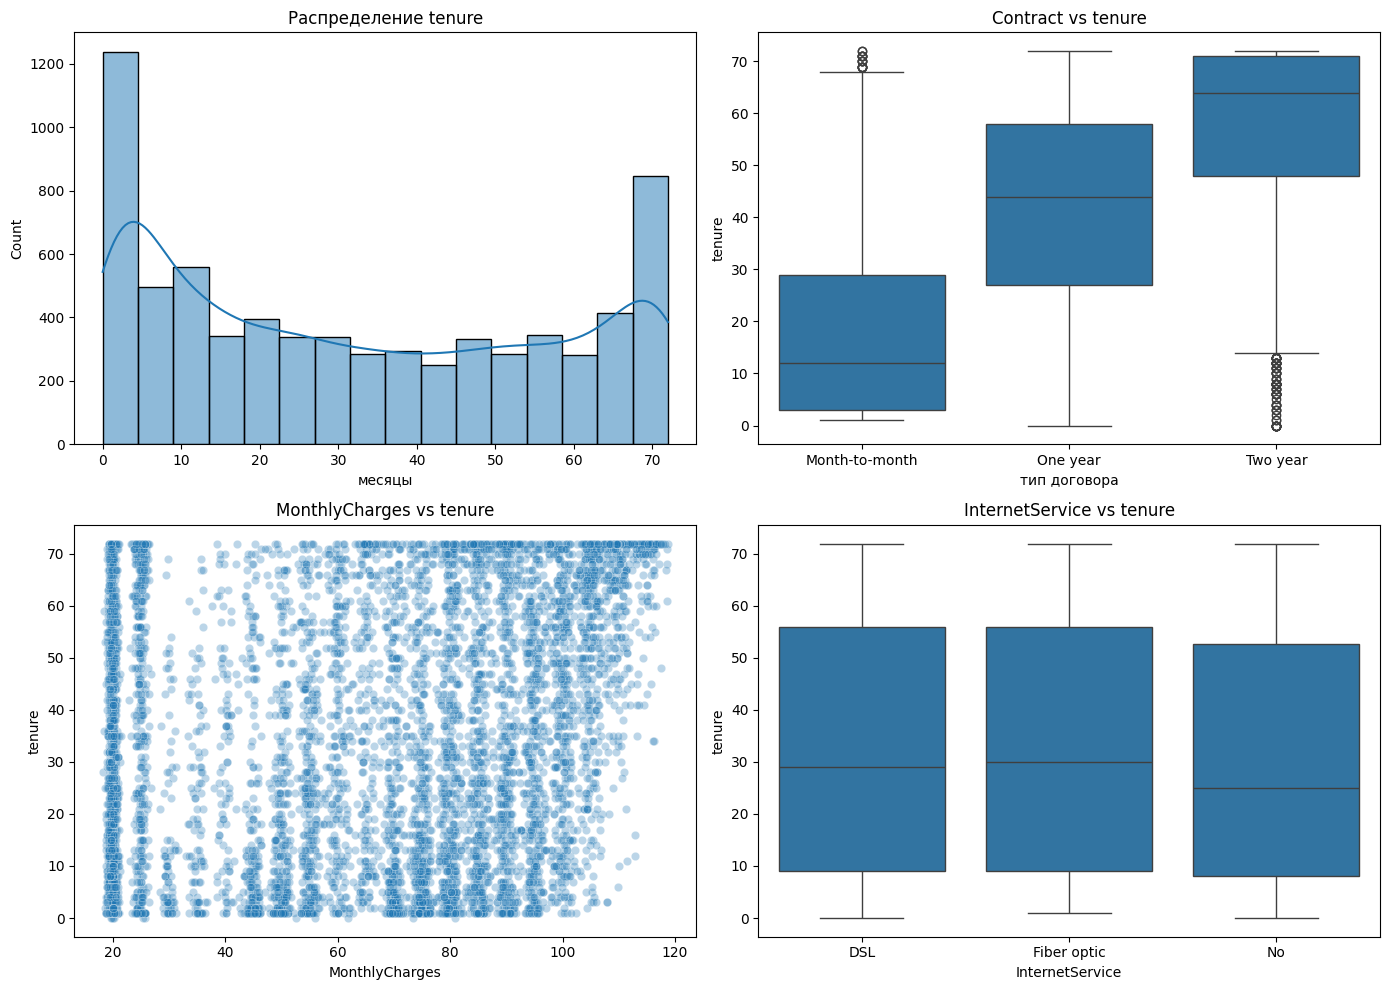

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# axes[0, 0] ...
# axes[0, 1] ...
# axes[1, 0] ...
# axes[1, 1] ...

plt.tight_layout()
plt.show()


### 2.3 - Очистка данных [1 балл]

**Описание задачи.** В отчете важно показать, что модель не учится на служебном ID и что проблемные значения не спрятаны внутри таблицы.

**Что сделать.** Удалите идентификатор клиента и проверьте пропуски.

**Ориентиры:**
- служебный идентификатор не попадает в признаки
- качество пропусков проверено
- пропуски обработаны явно при наличии

**Документация:**
- <https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.drop.html>
- <https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.isna.html>
- <https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.fillna.html>


In [ ]:
df_model = df.copy()

# очистка служебных колонок и пропусков


### 2.4 - Кодирование категориальных признаков [1 балл]

**Описание задачи.** После очистки данные должны стать похожи на матрицу признаков, которую можно передать в sklearn без ручных исключений.

**Что сделать.** Закодируйте все текстовые признаки.

**Ориентиры:**
- категориальные признаки переведены в числовой формат
- подготовленная таблица подходит для sklearn-моделей
- размер таблицы после кодирования показан

**Документация:**
- <https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.select_dtypes.html>
- <https://pandas.pydata.org/docs/reference/api/pandas.get_dummies.html>


In [ ]:
cat_cols = None

# кодирование категориальных столбцов


### 2.5 - Целевая переменная и признаки [1 балл]

**Описание задачи.** Это граница между бизнес-вопросом и входами модели: отдельно цель прогноза, отдельно признаки клиента.

**Что сделать.** Создайте `y` из `tenure`, а `X` из остальных признаков.

**Ориентиры:**
- подготовлены целевая переменная `y` и матрица признаков `X`
- целевая переменная не дублируется среди признаков
- показаны размеры `X` и `y`

**Документация:**
- <https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.drop.html>
- <https://pandas.pydata.org/docs/user_guide/indexing.html>


In [ ]:
y = None
X = None

# определите X и y


### 2.6 - Train/test split [1 балл]

**Описание задачи.** Чтобы отчет выглядел честно, качество нужно смотреть на клиентах, которые не участвовали в обучении.

**Что сделать.** Разделите данные на train и test.

**Ориентиры:**
- подготовлены train/test выборки
- размер test-части соответствует условию
- `random_state=42` сохранен для воспроизводимости
- показаны размеры получившихся частей

**Документация:**
- <https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html>


In [ ]:
X_train, X_test, y_train, y_test = None, None, None, None

# train/test-разбиение


---
## Задание 3 - Baseline-модели (7 баллов)

Теперь в отчете нужна отправная точка. Lead не хочет сразу сложную модель: сначала нужно показать, как работают простые варианты и какую планку качества они задают.


### 3.1 - Обучение baseline-моделей [2 балла]

**Описание задачи.** Baseline дает lead понятную точку отсчета: лучше ли будущая финальная модель простых рабочих вариантов.

**Что сделать.** Обучите 2-3 простые регрессионные модели без подбора гиперпараметров.

**Ориентиры:**
- обучены несколько простых baseline-моделей
- результаты моделей сохранены для дальнейшего сравнения
- модели обучены без подбора гиперпараметров

**Документация:**
- <https://scikit-learn.org/stable/modules/linear_model.html>
- <https://scikit-learn.org/stable/modules/neighbors.html>
- <https://scikit-learn.org/stable/modules/tree.html>
- <https://scikit-learn.org/stable/modules/ensemble.html>


In [ ]:
models = {}
preds = {}

# baseline-модели и их предсказания


### 3.2 - Метрики baseline [1 балл]

**Описание задачи.** Таблица метрик превращает набор предсказаний в аргумент для выбора модели.

**Что сделать.** Посчитайте MAE, RMSE и R2 для каждой модели.

**Ориентиры:**
- для каждой модели есть MAE, RMSE и R2
- результаты собраны в удобную таблицу
- таблица позволяет быстро сравнить baseline-модели

**Документация:**
- <https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_absolute_error.html>
- <https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html>
- <https://scikit-learn.org/stable/modules/generated/sklearn.metrics.r2_score.html>


In [ ]:
results = {}
results_df = None

# таблица метрик для baseline-моделей


### 3.3 - Визуализация baseline [2 балла]

**Описание задачи.** Графики помогают увидеть не только победителя по метрике, но и характер ошибок лучшей baseline-модели.

**Что сделать.** Постройте bar chart по RMSE и scatter plot `actual vs predicted` для лучшей baseline-модели.

**Ориентиры:**
- есть визуальное сравнение baseline-моделей по RMSE
- для лучшей baseline-модели показано соответствие фактических и предсказанных значений
- на графиках есть понятные подписи

**Документация:**
- <https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.html>
- <https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.scatter.html>


Примеры:

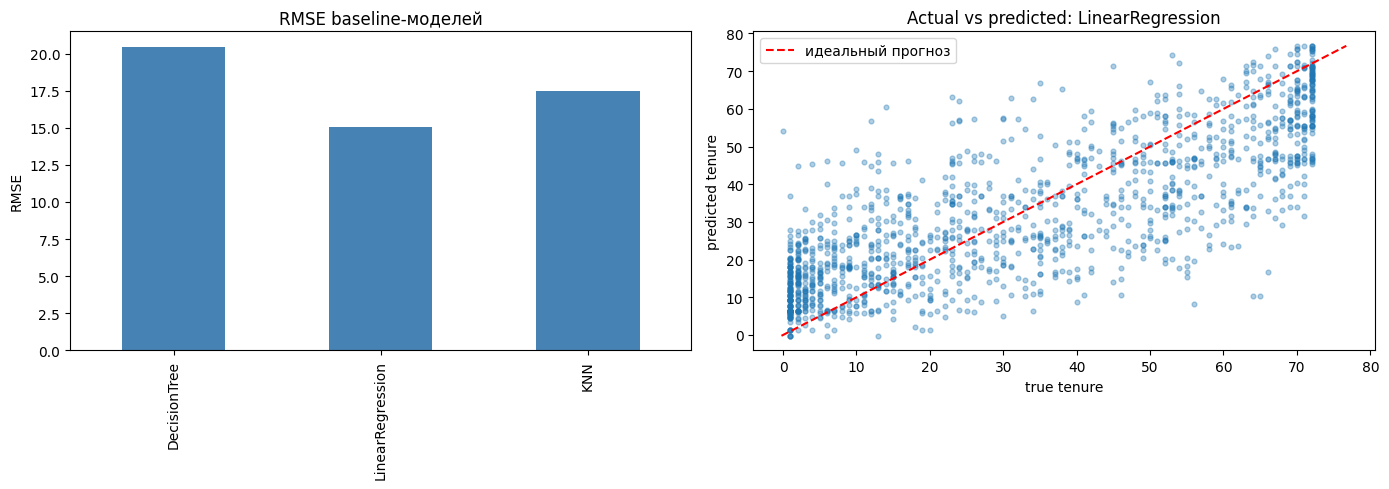

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
best_name = None
best_pred = None

# bar chart и actual vs predicted

plt.tight_layout()
plt.show()


### 3.4 - Выбор лучшей baseline-модели [1 балл]

**Описание задачи.** Lead ожидает короткий вывод: какая baseline-модель сейчас выглядит лучшим кандидатом и почему.

**Что сделать.** Напишите 1-2 предложения: какая baseline-модель лучшая и по каким числам вы это решили.

**Ориентиры:**
- модель названа явно
- вывод опирается на конкретные значения метрик
- причина выбора сформулирована коротко и по делу

**Документация:**
- <https://scikit-learn.org/stable/modules/model_evaluation.html>

Ответ:


### 3.5 - Порог качества baseline [1 балл]

**Описание задачи.** Порог качества помогает быстро понять, можно ли переходить к финальному кандидату или baseline пока слишком слабый.

**Что сделать.** Выведите лучший R2 среди baseline-моделей.

**Ориентиры:**
- показан лучший baseline R2
- порог `R2 >= 0.40` проверен явно

**Документация:**
- <https://scikit-learn.org/stable/modules/generated/sklearn.metrics.r2_score.html>


In [ ]:
best_r2 = None

# лучший baseline и проверка порога


---
## Задание 4 - Pipeline, GridSearchCV и финальная модель (7 баллов)

Финальная часть отчета показывает уже не черновой baseline, а аккуратно собранного кандидата: пайплайн, подбор настроек, тестовая оценка и короткое сравнение.


### 4.1 - Pipeline [1 балл]

**Описание задачи.** Пайплайн делает финальную модель воспроизводимой: preprocessing и модель соединены в один объект.

**Что сделать.** Подготовьте пайплайн `StandardScaler` + `RandomForestRegressor`.

**Ориентиры:**
- пайплайн объединяет масштабирование и регрессионную модель
- объект пайплайна готов к обучению
- структура пайплайна читается из кода

**Документация:**
- <https://scikit-learn.org/stable/modules/compose.html#pipeline>
- <https://scikit-learn.org/stable/modules/preprocessing.html>
- <https://scikit-learn.org/stable/modules/ensemble.html>


In [ ]:
pipe = None

# пайплайн финальной модели


### 4.2 - Сетка гиперпараметров [1 балл]

**Описание задачи.** Сетка настроек показывает, какие варианты финальной модели вы готовы сравнить перед рекомендацией.

**Что сделать.** Создайте `param_grid` минимум с двумя гиперпараметрами Random Forest.

**Ориентиры:**
- сетка содержит несколько вариантов настройки модели
- есть минимум два настраиваемых гиперпараметра
- размер сетки остается разумным для экзамена

**Документация:**
- <https://scikit-learn.org/stable/modules/grid_search.html>


In [ ]:
param_grid = {}

# сетка параметров


### 4.3 - GridSearchCV [1 балл]

**Описание задачи.** Подбор параметров нужен, чтобы рекомендация не выглядела случайным выбором одной настройки.

**Что сделать.** Подготовьте подбор гиперпараметров и покажите лучший найденный вариант.

**Ориентиры:**
- поиск настроек выполнен на train-части
- кросс-валидация и метрика соответствуют задаче регрессии
- лучшие параметры показаны в выводе

**Документация:**
- <https://scikit-learn.org/stable/modules/grid_search.html>
- <https://scikit-learn.org/stable/modules/model_evaluation.html#scoring-parameter>


In [ ]:
grid = None
best_model = None

# подбор гиперпараметров и лучший вариант


### 4.4 - Финальная оценка [2 балла]

**Описание задачи.** Финальная test-оценка отвечает на главный вопрос lead: как модель ведет себя на новых клиентах.

**Что сделать.** Посчитайте MAE, RMSE и R2 на тестовой выборке.

**Ориентиры:**
- финальная оценка сделана на test-части
- показаны MAE, RMSE и R2
- пороги `0.40` и `0.60` проверены явно

**Документация:**
- <https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_absolute_error.html>
- <https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html>
- <https://scikit-learn.org/stable/modules/generated/sklearn.metrics.r2_score.html>


In [ ]:
y_pred_final = None
final_mae = None
final_rmse = None
final_r2 = None

# оцените финальную модель


### 4.5 - Важность признаков [1 балл]

**Описание задачи.** Даже если модель работает хорошо, lead захочет понять, какие признаки сильнее всего влияют на прогноз.

**Что сделать.** Постройте horizontal bar chart для top-8 feature importances.

**Ориентиры:**
- показаны восемь наиболее важных признаков
- важности связаны с названиями колонок
- график отсортирован и читается без дополнительных пояснений

**Документация:**
- <https://scikit-learn.org/stable/modules/ensemble.html>
- <https://pandas.pydata.org/docs/reference/api/pandas.Series.sort_values.html>


Примеры:

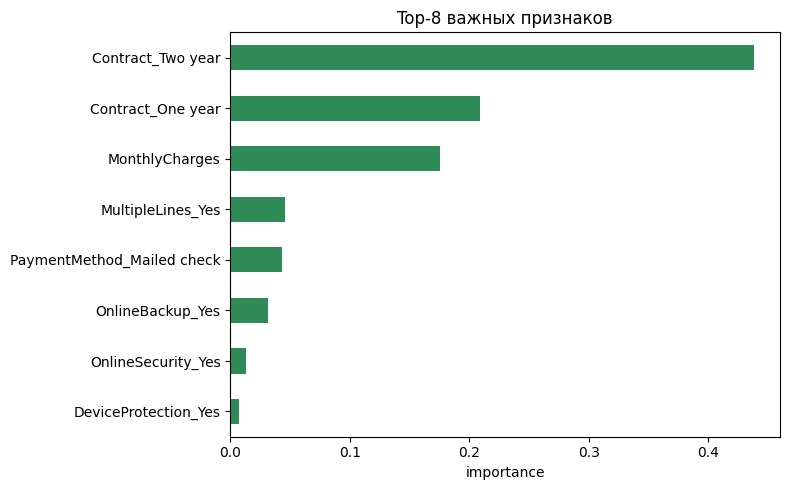

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
importances = None
imp = None

# feature importances

plt.tight_layout()
plt.show()


### 4.6 - Простое сравнение [1 балл]

**Описание задачи.** Финальный слайд должен честно показать, как tuned-кандидат выглядит рядом с лучшим baseline.

**Что сделать.** Сравните лучшую baseline-модель и tuned Random Forest по RMSE на test.

**Ориентиры:**
- baseline и tuned-модель сравниваются по одной test-метрике
- сравнение показано на простом bar chart
- вывод не предполагает, что tuned-модель обязана быть лучше

**Документация:**
- <https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html>
- <https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.bar.html>


Примеры:

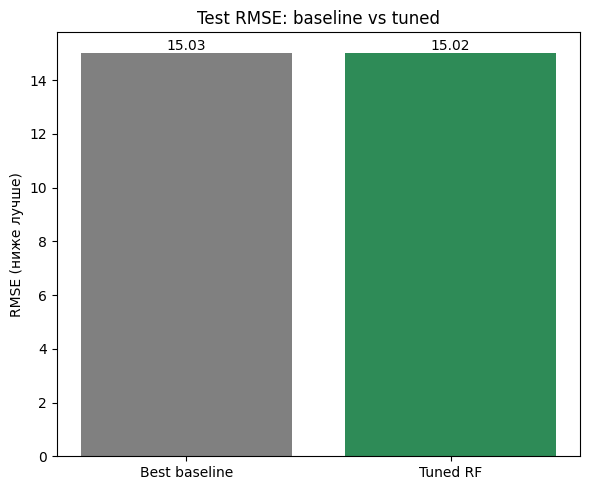

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
best_baseline_rmse = None
tuned_rmse = None

# best baseline vs tuned

plt.tight_layout()
plt.show()
